#📌 Problem Statement
This project aims to develop a deep learning-based solution that can classify aerial images into two categories — Bird or Drone — and optionally perform object detection to locate and label these objects in real-world scenes.
The solution will help in security surveillance, wildlife protection, and airspace safety where accurate identification between drones and birds is critical. The project involves building a Custom CNN classification model, leveraging transfer learning, and optionally implementing YOLOv8 for real-time object detection. The final solution will be deployed using Streamlit for interactive use.

**📌 Real-Time Business Use Cases
Wildlife Protection**


1. Detect birds near wind farms or airports to prevent accidents.


2. Security & Defense Surveillance=>
Identify drones in restricted airspace for timely alerts.


3. Airport Bird-Strike Prevention=>
Monitor runway zones for bird activity.


4. Environmental Research=>
Track bird populations using aerial footage without misclassification.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Classroom', 'Document (2).pdf', 'Document (1).pdf', 'Document.pdf', 'IMG-20231012-WA0002.jpg', 'Screenshot_20240323_182103_Chrome.jpg', 'Document 17_1.jpg', 'Sneha Chowdhury (23_ft_40).pdf', 'Screenshot_20240604_114655_PhonePe.jpg', 'Screenshot_20240709_130929_PhonePe.jpg', 'Picsart_24-10-06_18-46-54-038.jpg', 'Pujo vlog by Sneha Chowdhury ', 'inbound7235028289872345940.mp4', 'inbound7258355585974249637.jpg', 'BASIC PROBABILITY.docx', 'Sneha Chowdhury ', 'Copy of My Workouts (1).gsheet', 'Copy of My Workouts.gsheet', 'Copy of Flight Deals.gsheet', 'Document 44.pdf', 'Document 45.pdf', 'Document 46.pdf', 'Screenshot_20250705_133034_WhatsApp.jpg', 'SQL project submission.pdf', 'Untitled document.gdoc', 'Monthly sales template (1).gsheet', 'Monthly sales template.gsheet', 'Top 10 Websites to get Datasets for free.gdoc', 'Data  Visualizations.gdoc', 'Doc1.docx', 'final project-1.docx', 'Introduction to Internet of Things.pdf', 'sneha-chowdhury2025-07-08 14_09_37 (1).pdf', 'DOC-20251202-W

In [3]:
dataset_path = "/content/drive/MyDrive/classification_dataset"
print(os.listdir(dataset_path))

['train', 'valid', 'test']


In [4]:
train_dir = dataset_path + "/train"
valid_dir = dataset_path + "/valid"
test_dir  = dataset_path + "/test"

#Train=>
Image → Model predicts → Compare with true label → Error → Update weights

#Validation=>
New Image → Model predicts → Compare with truth → NO learning

#EDA Perform

In [5]:
import os
print(f"Contents of train_dir ({train_dir}):")
print(os.listdir(train_dir))

Contents of train_dir (/content/drive/MyDrive/classification_dataset/train):
['drone', 'bird']


**1.verifying:**

Are labels correct?
Are bounding boxes tight?
Any missing labels?
Any wrong annotations?

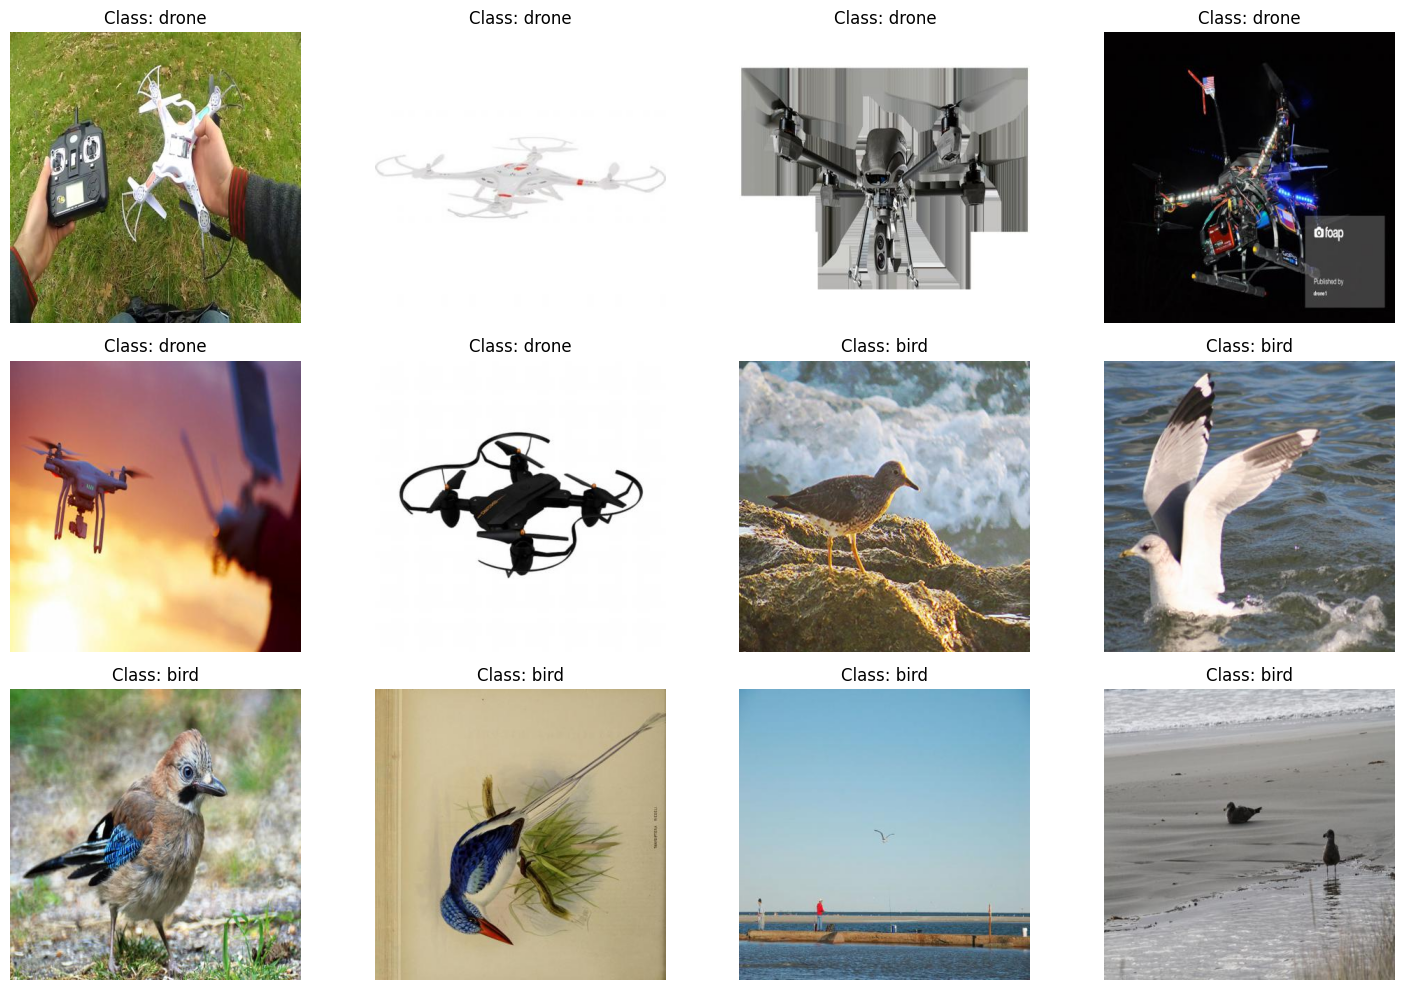

In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def display_random_images_with_labels(base_dir, num_images_per_class=6):#how many images per class to sample, here its 6
    classes = os.listdir(base_dir)
    if not classes:
        print(f"No classes found in {base_dir}")
        return

    plt.figure(figsize=(15, 10))
    plot_index = 0 #tracks subplot position

    for class_name in classes:
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            images_in_class = os.listdir(class_path)
            if not images_in_class:
                print(f"No images found in class: {class_name}")
                continue

            # Select random images from this class
            num_to_display = min(num_images_per_class, len(images_in_class))
            #It decides how many images you’re allowed to pick.
            #num_images_per_class → how many you want (e.g., 6)
            #len(images_in_class) → how many actually exist in that folder
            random_images_to_display = random.sample(images_in_class, k=num_to_display)

            for image_name in random_images_to_display:
                plot_index += 1
                if plot_index > 12: # Limit total images displayed for cleaner view
                    break

                image_path = os.path.join(class_path, image_name)
                image = cv2.imread(image_path)#Read image

                if image is None:
                    print(f"Could not load image: {image_path}")
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                plt.subplot(3, 4, plot_index)
                plt.imshow(image)
                plt.title(f"Class: {class_name}")
                plt.axis("off")
        if plot_index > 12:
            break

    plt.tight_layout()
    plt.show()

# Call the function to display images from the train_dir
display_random_images_with_labels(train_dir)


**image size check**

In [ ]:
from collections import Counter
import os
import cv2

sizes = []

# Assuming train_dir contains subdirectories like 'bird' and 'drone'
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            image = cv2.imread(image_path)
            if image is not None:
                sizes.append(image.shape[:2]) #(height, width)

sizes_count = Counter(sizes)
print(sizes_count)


Counter({(416, 416): 2662})


**Brightness Check**

In [ ]:
import os as os_module # Alias os to avoid potential conflicts
import numpy as np
import cv2 # Ensure cv2 is imported as it's used

brightness=[]
for class_name in os_module.listdir(train_dir):
  class_path=os_module.path.join(train_dir, class_name)
  # Check if it's a directory and if it contains files
  if os_module.path.isdir(class_path):
    for image_name in os_module.listdir(class_path):
      image_path=os_module.path.join(class_path, image_name)
      image=cv2.imread(image_path)
      if image is not None:
        gray=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))
print("Min brightness:", min(brightness))
print("Max brightness:", max(brightness))
print("Mean brightness:", np.mean(brightness))
print("Median brightness:", np.median(brightness))

Min brightness: 6.8881691475591715
Max brightness: 252.3482803254438
Mean brightness: 143.29521333856763
Median brightness: 133.04841785318047


**bounding box check**

In [ ]:
#missing label files
#For image classification, labels are typically determined by the
#directory structure (e.g., `train/bird`, `train/drone`), and there are
#no separate bounding box label files. Therefore, checks for missing labels or empty
# label files are not applicable in this context.

In [7]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

A tensor is simply a multi-dimensional array of numbers.for this project the image will convert to tensor and look like this(batch_size, channels, height, width) like (32,3,224, 224)

In [8]:
train_transforms=transforms.Compose([
    transforms.Resize((224,224)), #Resizes every image to:224 × 224 pixels
    transforms.RandomHorizontalFlip(),#Randomly flips the image horizontally
    transforms.RandomRotation(20),#Randomly rotates the image by a specified angle,Real-world images are not perfectly aligned
    transforms.ToTensor(),#Converts image → PyTorch tensor
    transforms.Normalize([0.5]*3, [0.5]*3) #Normalizes the image tensor by subtracting the mean and dividing by the standard deviation
])

In [9]:
valid_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [10]:
test_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [11]:
#load dataset
train_data=datasets.ImageFolder(train_dir, transform=train_transforms)
valid_data=datasets.ImageFolder(valid_dir, transform=valid_transforms)
test_data=datasets.ImageFolder(test_dir, transform=test_transforms)

In [12]:
#Create DataLoaders means batch system
train_loader=DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader=DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader=DataLoader(test_data, batch_size=32, shuffle=False)

In [13]:
print(train_data.class_to_idx)

{'bird': 0, 'drone': 1}


In [ ]:
#check one image batch
images, labels=next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [ ]:
import torch.nn as nn
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv=nn.Sequential(
        nn.Conv2d(3,32,3), #3 input, 32 output fiter, 3 X 3 kernel
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64,3),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    #  Step 1: Create dummy input
    dummy=torch.zeros(1,3,224,224)
    #  Step 2: Pass through conv layers
    dummy=self.conv(dummy)
    #  Step 3: Get flattened size automatically
    self.flatten_size=dummy.view(1,-1).shape[1]
    #  Step 4: Use it in Linear layer
    self.fc=nn.Sequential(
        nn.Flatten(),
        nn.Linear(self.flatten_size, 128), #nn.Linear(input_size, output_size), You are compressing a huge
        #feature vector into 128 important features
        nn.ReLU(),
        nn.Linear(128,1),#This layer takes the 128 numbers (features) and combines them into one single number.
        nn.Sigmoid()
    )
  def forward(self,x): #Input image → conv,Output → fc, Final prediction
    x=self.conv(x)
    x=self.fc(x)
    return x
model=CNN()

In [ ]:
#define loss and optimizer
import torch.optim as optim
criterion=nn.BCELoss() #binary cross entropy loss
optimizer=optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#model train and validation
#TRAINING: Image → Predict → Compare with truth → Find error → Fix weights
#VALIDATION:New Image → Predict → Check performance (no learning)
#REPEAT → Model improves every epoch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
num_epochs=10
train_losses=[]
val_losses=[]
val_accuracies=[]

# Use Early stopping and Model checkpoint
# Without early stopping: Model may overfit, Training wastes time
# With this:Stops when model stops improving ,Saves best version
best_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
  model.train()
  running_loss=0
  for images, labels in train_loader:
    outputs=model(images)
    loss= criterion(outputs.squeeze(), labels.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  model.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      outputs=model(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  if val_loss < best_loss:
    best_loss = val_loss
    torch.save(model.state_dict(), 'best_model.pth')
    counter = 0 # Reset counter when improvement occurs
  else:
    counter += 1
    if counter >= patience:
      print("Early stopping triggered!")
      break # Now correctly inside the 'for epoch' loop

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 56.5302
Val Loss: 7.8519
Accuracy: 0.6968, Precision: 0.7600, Recall: 0.5911, F1: 0.6650
Epoch2
Train Loss: 44.3888
Val Loss: 7.9033
Accuracy: 0.7127, Precision: 0.6775, Recall: 0.8311, F1: 0.7465
Epoch3
Train Loss: 39.2476
Val Loss: 7.1784
Accuracy: 0.7421, Precision: 0.7033, Recall: 0.8533, F1: 0.7711
Epoch4
Train Loss: 36.5140
Val Loss: 6.8713
Accuracy: 0.7579, Precision: 0.7360, Recall: 0.8178, F1: 0.7747
Epoch5
Train Loss: 32.9726
Val Loss: 6.5100
Accuracy: 0.7986, Precision: 0.7982, Recall: 0.8089, F1: 0.8035
Epoch6
Train Loss: 29.8616
Val Loss: 6.4080
Accuracy: 0.7760, Precision: 0.7250, Recall: 0.9022, F1: 0.8040
Epoch7
Train Loss: 26.9358
Val Loss: 6.6006
Accuracy: 0.7851, Precision: 0.7390, Recall: 0.8933, F1: 0.8089
Epoch8
Train Loss: 25.1261
Val Loss: 6.1700
Accuracy: 0.8077, Precision: 0.7893, Recall: 0.8489, F1: 0.8180
Epoch9
Train Loss: 22.2838
Val Loss: 6.4478
Accuracy: 0.8303, Precision: 0.8571, Recall: 0.8000, F1: 0.8276
Epoch10
Train Loss: 21.0332


Validation loss = how wrong your model is on unseen data (validation set)

Validation loss fluctuates because your model is learning patterns but also slightly overfitting and making inconsistent predictions on unseen data

Accuracy only checks: Correct or Wrong

Loss checks: HOW wrong or HOW confident

In [ ]:
#model evaluation
#model.load_state_dict(torch.load("best_model.pth"))
model.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=186624, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    outputs=model(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[109  12]
 [ 21  73]]


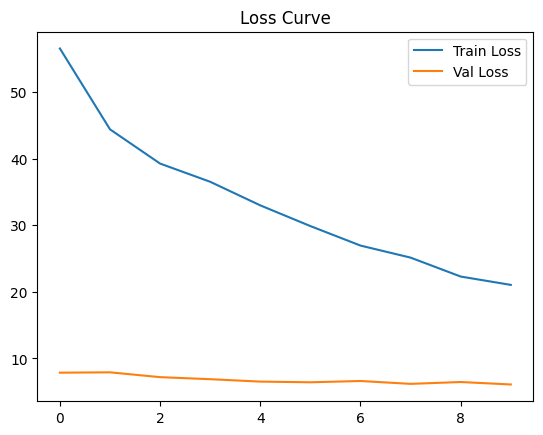

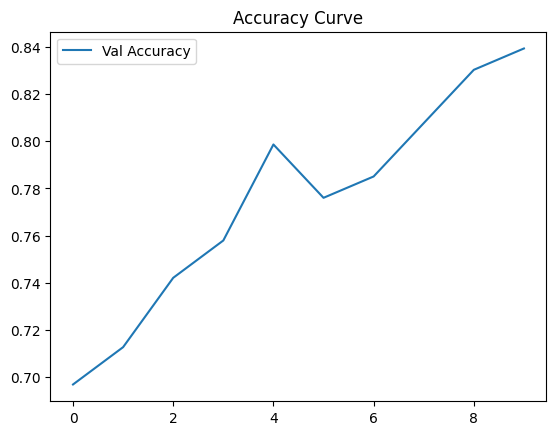

In [ ]:
#loss graph
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()
#accuracy graph
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Problem	Meaning

Train loss ↓ but Val loss ↑=Overfitting

Both losses high=	Underfitting

The custom CNN achieved a maximum validation accuracy of 85.75%, with a well-balanced precision and recall. However, validation loss fluctuations indicate mild overfitting, suggesting the need for regularization or transfer learning for further improvement.

# Now we will work on pre-trained model to learn for better accuracy.

**ResNet (Simple Explanation)**

ResNet (Residual Network) is a deep learning model designed to solve the problem of vanishing gradients when networks become very deep. It introduces skip connections (shortcut connections), which allow the model to skip some layers and pass information directly to deeper layers.

👉 In simple terms:
ResNet helps the model learn deeper without losing information.

🔥 Key Features
Uses skip connections
Enables very deep networks (50, 101, 152 layers)
Solves vanishing gradient problem
Higher accuracy than simple CNNs
More stable training

In [ ]:
#convert it to imagenet structure for model to better understand
#For each pixel (for each channel R, G, B):
#normalized_pixel = (pixel - mean) / std
#🔸 Example (Red channel)
#Let’s say:
#pixel value (after ToTensor) = 0.6
#mean = 0.485
#std = 0.229
#(0.6 - 0.485) / 0.229 ≈ 0.50
#👉 That becomes the new pixel value
transforms.Normalize(mean=[0.485, 0.456,0.406],
                     std=[0.229, 0.224, 0,225])

Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0, 225])

In [ ]:
from torchvision import models
import torch.nn as nn
restnet=models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


#Frozen Model (Feature Extractor)

👉 Model uses:

Pretrained features (ImageNet)
Only learns final classifier

**Behavior:**
Fast training,
Less overfitting,
But limited learning

👉 That’s why:

Accuracy plateaus ~95%
Loss unstable (not adapting deeply)

In [ ]:
#We freeze layers to reuse pretrained knowledge and only train the parts needed for our new task
for param in model.parameters():
  param.requires_grad=False

In [ ]:
#replace final layer
#You are replacing the original classifier of the pretrained model (like ResNet)
#Because:Original model was trained for 1000 classes (ImageNet) ❌
#You need binary classification (bird vs drone) ✅
restnet.fc=nn.Sequential(
    nn.Linear(restnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,1),
    nn.Sigmoid()
    )

**dropout=>**

This means:
50% of neurons will be randomly deactivated during each forward pass

Important: It changes every time

Each training step:

Different neurons are dropped

👉 So the model never relies on specific neurons

🧠 Why do we use Dropout?
🔥 Main problem: Overfitting

Without dropout:

Model memorizes training data
Performs poorly on new data ❌

In [ ]:
#Loss + optimizer
import torch.optim as optim
criterion=nn.BCELoss()
optimizer=optim.Adam(restnet.fc.parameters(), lr=0.001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# These lines should ideally be inside the training/validation loop where images and labels are defined.
# For now, commenting them out to avoid a NameError if run independently, but the core device fix is applied.
# images = images.to(device)
# labels = labels.to(device)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=186624, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [ ]:
#model train and validation
#TRAINING: Image → Predict → Compare with truth → Find error → Fix weights
#VALIDATION:New Image → Predict → Check performance (no learning)
#REPEAT → Model improves every epoch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
num_epochs=5
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

# Ensure restnet is on the correct device
restnet.to(device)

for epoch in range(num_epochs):
  restnet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=restnet(images) # Changed 'model' to 'restnet'
    loss= criterion(outputs.squeeze(), labels.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  restnet.eval() # Changed 'model.eval()' to 'restnet.eval()'
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=restnet(images) # Changed 'model' to 'restnet'
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  #Use Early stopping and Model checkpoint
  #Without early stopping: Model may overfit, Training wastes time
  #With this:Stops when model stops improving ,Saves best version
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(restnet.state_dict(), 'best_fine_tuned_freeze_model.pth') # Changed 'model' to 'restnet'
    counter = 0
  else:
    counter += 1
    if counter >= patience:
      print("Early stopping triggered!")
      break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 20.4843
Val Loss: 2.5567
Accuracy: 0.9389, Precision: 0.9160, Recall: 0.9689, F1: 0.9417
Epoch2
Train Loss: 12.4526
Val Loss: 1.7831
Accuracy: 0.9525, Precision: 0.9513, Recall: 0.9556, F1: 0.9534
Epoch3
Train Loss: 16.3268
Val Loss: 2.4964
Accuracy: 0.9480, Precision: 1.0000, Recall: 0.8978, F1: 0.9461
Epoch4
Train Loss: 9.9498
Val Loss: 1.6389
Accuracy: 0.9570, Precision: 0.9769, Recall: 0.9378, F1: 0.9569
Epoch5
Train Loss: 10.5939
Val Loss: 1.5667
Accuracy: 0.9593, Precision: 0.9520, Recall: 0.9689, F1: 0.9604


In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs=restnet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[114   7]
 [  3  91]]


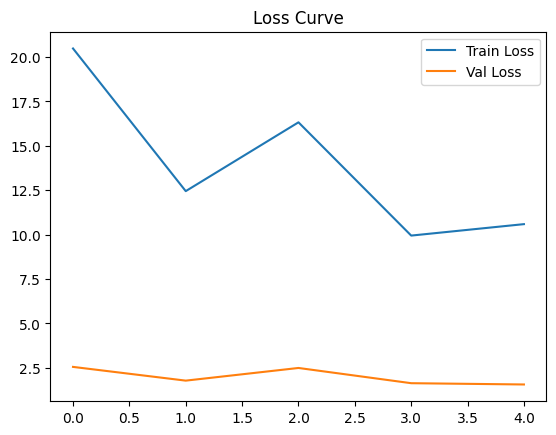

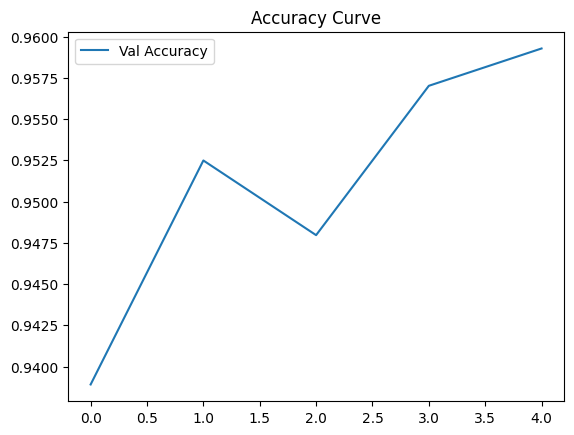

In [ ]:
#loss graph
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()
#accuracy graph
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

#Unfrozen Model (Fine-Tuning)

👉 Model updates:

All layers
Adjusts features specifically for bird vs drone
**Behavior:**
Learns better feature representation
Adapts to your dataset

👉 That’s why:

Accuracy jumps to 98.6%
Loss decreases smoothly

In [ ]:
#fine tuning
for param in restnet.layer4.parameters():
  param.requires_grad=True
optimizer=optim.Adam(restnet.parameters(), lr=1e-5)

What is layer4?

In ResNet:

layer1 → basic features (edges)

layer2 → shapes

layer3 → patterns

layer4 → high-level features (objects)

In [ ]:
#model train and validation
#TRAINING: Image → Predict → Compare with truth → Find error → Fix weights
#VALIDATION:New Image → Predict → Check performance (no learning)
#REPEAT → Model improves every epoch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
num_epochs=5
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
  restnet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=restnet(images)
    loss= criterion(outputs.squeeze(), labels.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  restnet.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=restnet(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(restnet.state_dict(), 'best_fine_tuned_restnet_unfreeze_model.pth')
    counter = 0
  else:
    counter += 1
    if counter >= patience:
      print("Early stopping triggered!")
      break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


Epoch1
Train Loss: 43.5927
Val Loss: 7.0793
Accuracy: 0.9887, Precision: 0.9825, Recall: 0.9956, F1: 0.9890
Epoch2
Train Loss: 43.4847
Val Loss: 7.0714
Accuracy: 0.9910, Precision: 0.9868, Recall: 0.9956, F1: 0.9912
Epoch3
Train Loss: 43.4997
Val Loss: 7.0507
Accuracy: 0.9910, Precision: 0.9868, Recall: 0.9956, F1: 0.9912
Epoch4
Train Loss: 43.4588
Val Loss: 7.0726
Accuracy: 0.9910, Precision: 0.9868, Recall: 0.9956, F1: 0.9912
Epoch5
Train Loss: 43.5177
Val Loss: 7.0601
Accuracy: 0.9910, Precision: 0.9868, Recall: 0.9956, F1: 0.9912


Step 1: Load pretrained model

Step 2: Freeze all layers

Step 3: Train last layer (fast learning)

Step 4: Unfreeze last block (layer4)

Step 5: Train again with small LR (fine-tuning)

In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device) # Move images to the same device as the model
    outputs=restnet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[120   1]
 [  2  92]]


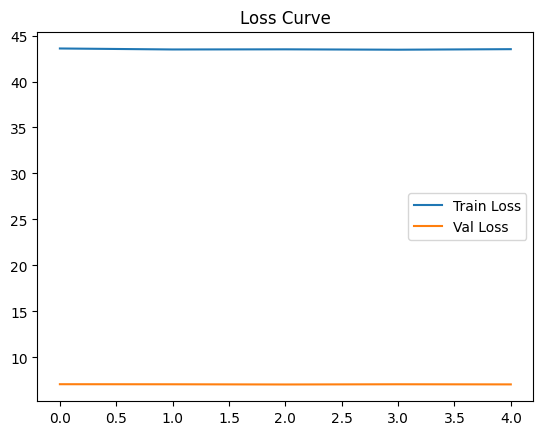

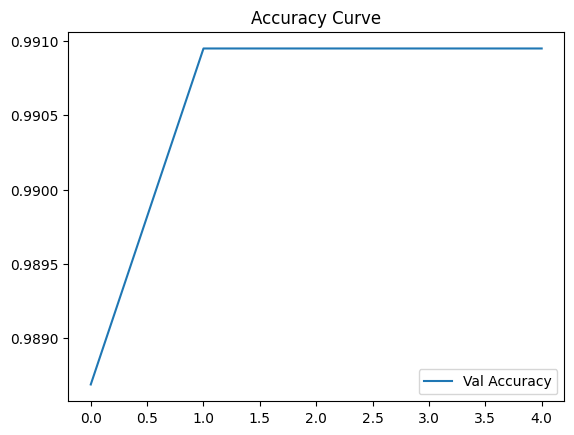

In [ ]:
#loss graph
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()
#accuracy graph
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
import os
#1. Check SAME images in train & val (data leakage)
train_images = set(os.listdir("/content/dataset/train/images"))
val_images = set(os.listdir("/content/dataset/valid/images"))
common = train_images.intersection(val_images)
print("Common images:", len(common))

if len(common) > 0:
    print("⚠️ Data Leakage Found!")
    print(list(common)[:10])  # show few
else:
    print("✅ No overlap between train and val")

#Next Transfer Learning=> MobileNetV2

**MobileNet (Simple Explanation)**

MobileNet is a lightweight deep learning model designed for fast and efficient image processing, especially on devices like mobile phones and embedded systems. Instead of using normal convolutions, it uses a special technique called depthwise separable convolution, which splits the computation into two smaller steps. This reduces the number of parameters and computation while still maintaining good accuracy.

👉 In simple terms:
MobileNet is built to be fast, small, and efficient, making it ideal when you have limited resources or need real-time performance.

🔥 Key Features
Very low computation cost
Faster training and inference
Uses Depthwise + Pointwise convolution
Suitable for real-time applications (like YOLO, mobile apps)
Slightly lower accuracy than heavy models, but very efficient

In [ ]:
transforms.Normalize(mean=[0.485, 0.456,0.406],
                     std=[0.229, 0.224, 0.224]  )

Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])

In [ ]:
from torchvision import models
import torch.nn as nn
mobilenet=models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 85.7MB/s]


In [ ]:
for param in mobilenet.classifier.parameters():
  param.requires_grad=False

In [ ]:
mobilenet.classifier[1]=nn.Sequential( #model.classifier =[ Dropout, Linear] So you are replacing:the original last layer
#(1000 classes) with your custom classifier ✅
    nn.Linear(mobilenet.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,1),
    nn.Sigmoid()
    )

In [ ]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mobilenet.classifier[1].parameters(), lr=0.001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mobilenet.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
#model train and validation
#TRAINING: Image → Predict → Compare with truth → Find error → Fix weights
#VALIDATION:New Image → Predict → Check performance (no learning)
#REPEAT → Model improves every epoch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
num_epochs=7
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
  mobilenet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=mobilenet(images)
    loss= criterion(outputs.squeeze(), labels.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  mobilenet.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=mobilenet(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  #Use Early stopping and Model checkpoint
  #Without early stopping: Model may overfit, Training wastes time
  #With this:Stops when model stops improving ,Saves best version

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(mobilenet.state_dict(), 'best_fine_tuned_mobilenet_freeze_model.pth')
    counter = 0
  else:
    counter += 1
    if counter >= patience:
        print("Early stopping triggered!")
        break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 45.8638
Val Loss: 7.8531
Accuracy: 0.8326, Precision: 1.0000, Recall: 0.6711, F1: 0.8032
Epoch2
Train Loss: 45.7064
Val Loss: 7.6213
Accuracy: 0.8824, Precision: 1.0000, Recall: 0.7689, F1: 0.8693
Epoch3
Train Loss: 46.0046
Val Loss: 7.3280
Accuracy: 0.9321, Precision: 0.9949, Recall: 0.8711, F1: 0.9289
Epoch4
Train Loss: 46.1348
Val Loss: 7.2521
Accuracy: 0.9593, Precision: 0.9600, Recall: 0.9600, F1: 0.9600
Epoch5
Train Loss: 45.6836
Val Loss: 7.2693
Accuracy: 0.9502, Precision: 0.9903, Recall: 0.9111, F1: 0.9491
Epoch6
Train Loss: 45.4081
Val Loss: 7.3225
Accuracy: 0.9389, Precision: 0.9853, Recall: 0.8933, F1: 0.9371
Early stopping triggered!


In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device) # Move images to the same device as the model
    outputs=mobilenet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[120   1]
 [ 17  77]]


In [ ]:
for param in mobilenet.classifier.parameters():
  param.requires_grad=True

In [ ]:
#model train and validation
#TRAINING: Image → Predict → Compare with truth → Find error → Fix weights
#VALIDATION:New Image → Predict → Check performance (no learning)
#REPEAT → Model improves every epoch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
num_epochs=5
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
  mobilenet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=mobilenet(images)
    loss= criterion(outputs.squeeze(), labels.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  mobilenet.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=mobilenet(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  #Use Early stopping and Model checkpoint
  #Without early stopping: Model may overfit, Training wastes time
  #With this:Stops when model stops improving ,Saves best version

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(mobilenet.state_dict(), 'best_fine_tuned_mobilenet_unfreeze_model.pth')
    counter = 0
  else:
    counter += 1
    if counter >= patience:
        print("Early stopping triggered!")
        break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 45.6329
Val Loss: 7.3315
Accuracy: 0.9502, Precision: 0.9394, Recall: 0.9644, F1: 0.9518
Epoch2
Train Loss: 45.5248
Val Loss: 7.2571
Accuracy: 0.9480, Precision: 0.9903, Recall: 0.9067, F1: 0.9466
Epoch3
Train Loss: 45.5836
Val Loss: 7.3433
Accuracy: 0.9299, Precision: 0.9850, Recall: 0.8756, F1: 0.9271
Epoch4
Train Loss: 45.2710
Val Loss: 7.2893
Accuracy: 0.9570, Precision: 0.9478, Recall: 0.9689, F1: 0.9582
Epoch5
Train Loss: 45.3982
Val Loss: 7.2358
Accuracy: 0.9615, Precision: 0.9643, Recall: 0.9600, F1: 0.9621


In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device) # Move images to the same device as the model
    outputs=mobilenet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[119   2]
 [  2  92]]


MobileNetV2 (Transfer Learning – Technical Explanation):
For this project, MobileNetV2 pretrained on ImageNet was used as a feature extractor. Initially, all convolutional layers were frozen to retain the learned low-level and high-level features, and only the final classifier layer was replaced and trained for the binary classification task (bird vs drone). This approach resulted in strong performance with high accuracy and low false positives and false negatives, indicating good generalization on unseen data.

Further fine-tuning was attempted by unfreezing the last few layers and retraining with a lower learning rate. However, this led to a degradation in performance, particularly an increase in false negatives, suggesting slight overfitting and disruption of pretrained feature representations. This behavior is common in lightweight architectures like MobileNetV2 when applied to relatively small datasets.

Therefore, the frozen MobileNetV2 model was selected as the optimal configuration, as it achieved a better balance between accuracy, generalization, and computational efficiency, making it suitable for real-time deployment scenarios.

# next transfer learning = Efficientnet_V2

**EfficientNet** is a powerful deep learning model used for image classification that is designed to give high accuracy with less computation. Unlike older models that just increase depth (more layers) or width (more neurons), EfficientNet uses a smart method called compound scaling—it increases depth, width, and image resolution together in a balanced way. This makes the model both efficient and strong.

In simple terms, EfficientNet tries to get the best performance without making the model unnecessarily big or slow.

Key things it does:
It extracts features from images like edges, textures, shapes (same as CNNs)
It uses optimized building blocks called MBConv (Mobile Inverted Bottleneck Convolution) which are lightweight but powerful
It scales properly (not randomly increasing size), so it avoids wasting computation
Features:
High accuracy even compared to heavy models like ResNet
Less parameters → faster training & inference
Better generalization → reduces overfitting
Comes in versions: EfficientNetB0 to B7
B0 = smallest, fastest
B7 = largest, most accurate
In your project (bird vs drone):

EfficientNet is useful because:

It can detect fine differences between bird and drone (very important)
Works well even if dataset is not very large
Gives better performance than your custom CNN in most cases

In [15]:
transforms.Normalize(mean=[0.485, 0.456,0.406],
                     std=[0.229, 0.224, 0.224]  )

Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])

In [44]:
import torch
import torch.nn as nn
from torchvision import models
# Load pretrained EfficientNetB0
efficientnet = models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [50]:
#freeze layers
for param in efficientnet.features.parameters():
  param.requires_grad=False

In [51]:
import torch
in_features =efficientnet.classifier[1].in_features # EfficientNetB0's feature extractor output is 1280
#-1 means last layer in the sequence,1280 is the feature size produced by EfficientNet,
#and your classifier uses it as input to predict bird vs drone
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)   # No Sigmoid
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet = efficientnet.to(device)

In [52]:
criterion = nn.BCEWithLogitsLoss()   # IMPORTANT
optimizer = torch.optim.Adam(efficientnet.parameters(), lr=1e-3)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

num_epochs=5
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet.to(device)

for epoch in range(num_epochs):
  efficientnet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=efficientnet(images)
    loss= criterion(outputs.squeeze(), labels.float()) # outputs.squeeze() will now be [batch_size] if num_classes=1
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  efficientnet.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=efficientnet(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  #Use Early stopping and Model checkpoint
  #Without early stopping: Model may overfit, Training wastes time
  #With this:Stops when model stops improving ,Saves best version

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(efficientnet.state_dict(), 'best_fine_tuned_efficientnet_freeze_model.pth')
    counter = 0
  else:
    counter += 1
    if counter >= patience:
        print("Early stopping triggered!")
        break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 20.4869
Val Loss: 1.9403
Accuracy: 0.9570, Precision: 0.9682, Recall: 0.9467, F1: 0.9573
Epoch2
Train Loss: 13.0275
Val Loss: 1.7890
Accuracy: 0.9548, Precision: 0.9638, Recall: 0.9467, F1: 0.9552
Epoch3
Train Loss: 12.6027
Val Loss: 1.8427
Accuracy: 0.9548, Precision: 0.9724, Recall: 0.9378, F1: 0.9548
Epoch4
Train Loss: 11.0441
Val Loss: 1.8789
Accuracy: 0.9525, Precision: 0.9766, Recall: 0.9289, F1: 0.9522
Epoch5
Train Loss: 11.8909
Val Loss: 1.6816
Accuracy: 0.9548, Precision: 0.9596, Recall: 0.9511, F1: 0.9554


In [54]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device) # Move images to the same device as the model
    outputs=efficientnet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[119   2]
 [  3  91]]


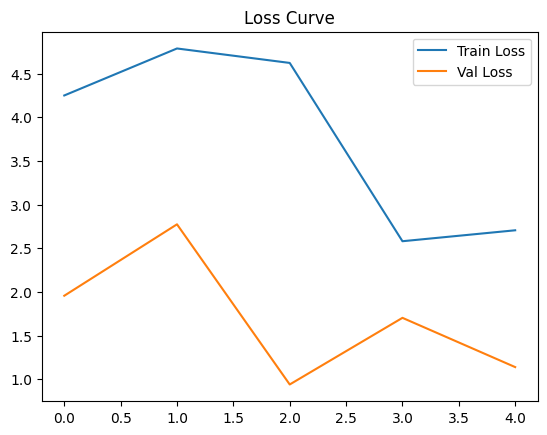

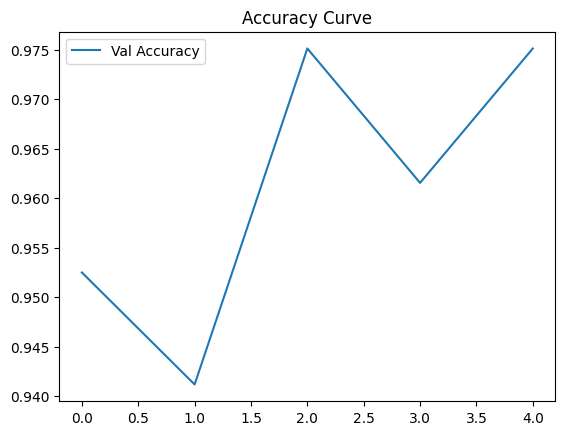

In [ ]:
#loss graph
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()
#accuracy graph
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
#fine tuning
# Unfreeze last few layers
for param in efficientnet.features[-3:].parameters():
    param.requires_grad = True

# Lower learning rate
optimizer = torch.optim.Adam(efficientnet.parameters(), lr=1e-5)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

num_epochs=5
train_losses=[]
val_losses=[]
val_accuracies=[]

best_val_loss = float('inf')
patience = 3
counter = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet.to(device)

for epoch in range(num_epochs):
  efficientnet.train()
  running_loss=0
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs=efficientnet(images)
    loss= criterion(outputs.squeeze(), labels.float()) # outputs.squeeze() will now be [batch_size] if num_classes=1
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  train_losses.append(running_loss)

  #validation
  efficientnet.eval()
  val_loss=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs=efficientnet(images)
      loss=criterion(outputs.squeeze(), labels.float())
      val_loss+=loss.item()
      preds=(outputs.squeeze()> 0.5).int()
      all_preds.extend(preds.tolist())#all_preds  = [1, 0, 1, 1]
      all_labels.extend(labels.tolist())#all_labels = [1, 0, 0, 1]
  val_losses.append(val_loss)

  # Early stopping logic
  #Use Early stopping and Model checkpoint
  #Without early stopping: Model may overfit, Training wastes time
  #With this:Stops when model stops improving ,Saves best version

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(efficientnet.state_dict(), 'best_fine_tuned_efficientnet_unfreeze_model.pth')
    counter = 0
  else:
    counter += 1
    if counter >= patience:
        print("Early stopping triggered!")
        break

  #Metrics
  accuracy= sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)#p=predicted, l=actual_level
  precision=precision_score(all_labels, all_preds)
  recall=recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)
  val_accuracies.append(accuracy)
  print(f"Epoch{epoch+1}")
  print(f"Train Loss: {running_loss:.4f}")
  print(f"Val Loss: {val_loss:.4f}")
  print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch1
Train Loss: 1.3431
Val Loss: 1.0168
Accuracy: 0.9706, Precision: 0.9775, Recall: 0.9644, F1: 0.9709
Epoch2
Train Loss: 1.7444
Val Loss: 1.0614
Accuracy: 0.9729, Precision: 0.9863, Recall: 0.9600, F1: 0.9730
Epoch3
Train Loss: 1.4879
Val Loss: 0.9331
Accuracy: 0.9729, Precision: 0.9819, Recall: 0.9644, F1: 0.9731
Epoch4
Train Loss: 1.3671
Val Loss: 0.9785
Accuracy: 0.9774, Precision: 0.9864, Recall: 0.9689, F1: 0.9776
Epoch5
Train Loss: 1.1210
Val Loss: 0.8922
Accuracy: 0.9774, Precision: 0.9821, Recall: 0.9733, F1: 0.9777


In [ ]:
#test accuracy
from sklearn.metrics import confusion_matrix, classification_report
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device) # Move images to the same device as the model
    outputs=efficientnet(images)
    preds=(outputs.squeeze()> 0.5).int()
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[116   5]
 [  4  90]]


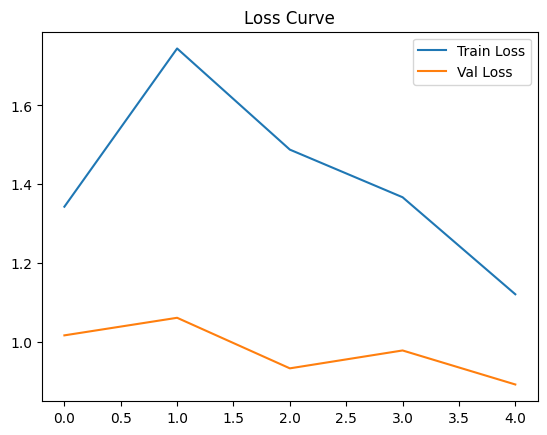

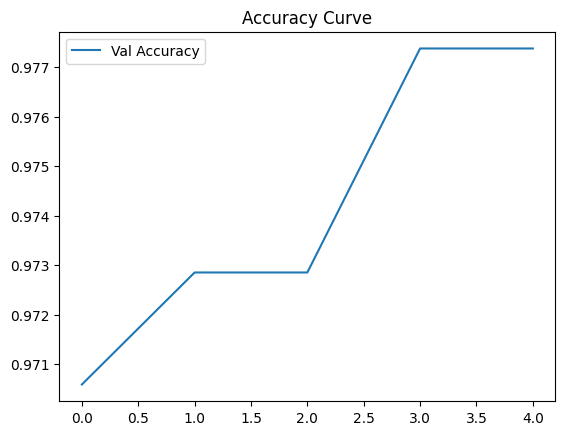

In [ ]:
#loss graph
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()
#accuracy graph
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

EfficientNetB0 is a CNN architecture based on compound scaling, which uniformly scales network depth, width, and input resolution using a fixed scaling coefficient. This results in better performance with fewer parameters compared to traditional architectures.

In this implementation:

A pretrained EfficientNetB0 model (trained on ImageNet) was used.
The classifier head was replaced to match the number of target classes.
Initial layers were frozen to retain low-level feature extraction.
Higher layers were unfrozen for fine-tuning to adapt to domain-specific features.
A low learning rate (e.g., 1e-5) was used during fine-tuning to prevent large weight updates.

This approach improves generalization, reduces overfitting, and achieves better performance on small or medium-sized datasets.

In [56]:
import pandas as pd
results = []
results.append({
    "Model": "Custom CNN",
    "Accuracy": 0.8394,
    "Precision": 0.8812,
    "Recall": 0.7911,
    "F1 Score": 0.8337
})
results.append({
    "Model": "ResNet Freeze",
    "Accuracy": 0.9593,
    "Precision": 0.9520,
    "Recall": 0.9689,
    "F1 Score": 0.9604
})
results.append({
    "Model": "ResNet Unfreeze",
    "Accuracy": 0.9910,
    "Precision": 0.9868,
    "Recall": 0.9956,
    "F1 Score": 0.9912
})
results.append({
    "Model": "MobileNet Freeze",
    "Accuracy": 0.9593,
    "Precision": 0.9600,
    "Recall": 0.9600,
    "F1 Score": 0.9600
})
results.append({
    "Model": "EfficientNet Freeze",
    "Accuracy": 0.9751,
    "Precision": 0.9735,
    "Recall": 0.9778,
    "F1 Score": 0.9756
})
results.append({
    "Model": "EfficientNet Unfreeze",
    "Accuracy": 0.9751,
    "Precision": 0.9735,
    "Recall": 0.9778,
    "F1 Score": 0.9756
})
df= pd.DataFrame(results)
df

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.8394,0.8812,0.7911,0.8337
1,ResNet Freeze,0.9593,0.9520,0.9689,0.9604
2,ResNet Unfreeze,0.9910,0.9868,0.9956,0.9912
3,MobileNet Freeze,0.9593,0.9600,0.9600,0.9600
4,EfficientNet Freeze,0.9751,0.9735,0.9778,0.9756
5,EfficientNet Unfreeze,0.9751,0.9735,0.9778,0.9756
